<a href="https://colab.research.google.com/github/jolineuichanco/DataAnalytics/blob/main/demos/Week11_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 11**

In [1]:
import kagglehub
import os

# Download latest version of customer segmentation data
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")
# The CSV file is named 'Mall_Customers.csv'
csv_file_path = os.path.join(path, 'Mall_Customers.csv')


Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.


In [2]:
import pandas as pd

# Load the CSV into a pandas DataFrame
df = pd.read_csv(csv_file_path)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


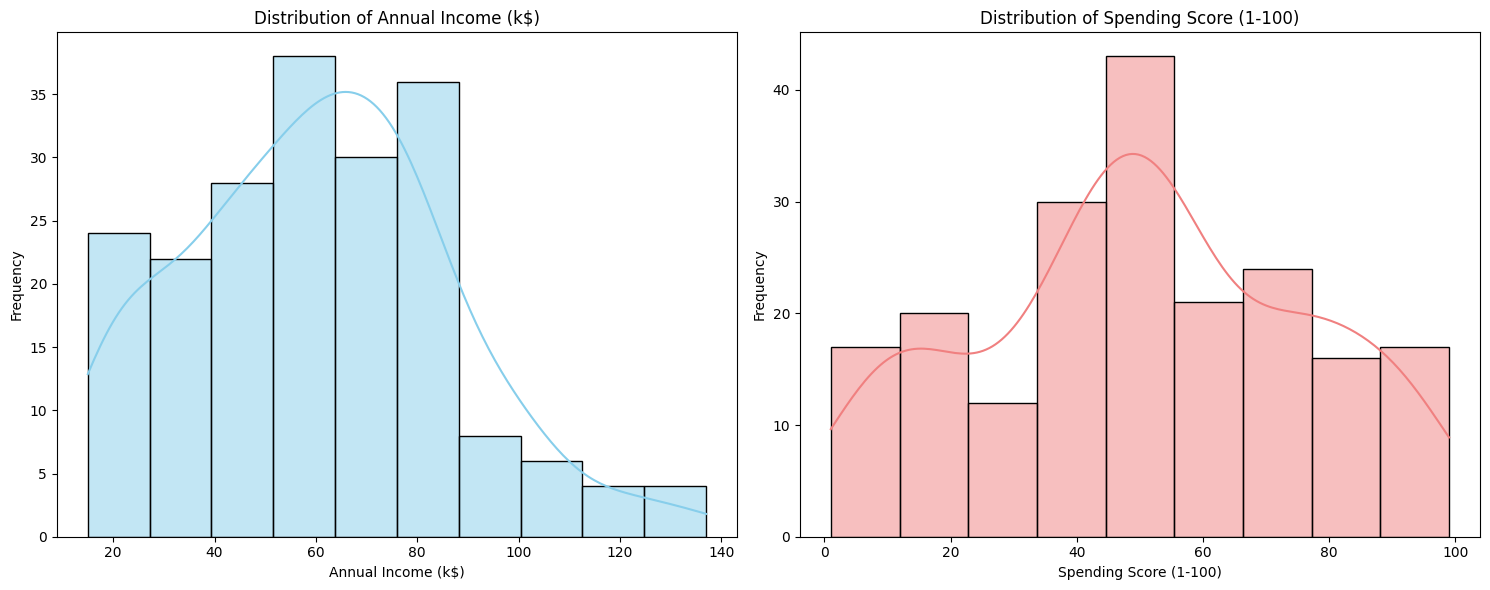

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the matplotlib figure and axes for two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot histogram for 'Annual Income (k$)'
sns.histplot(df['Annual Income (k$)'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Annual Income (k$)')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Frequency')

# Plot histogram for 'Spending Score (1-100)'
sns.histplot(df['Spending Score (1-100)'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Spending Score (1-100)')
axes[1].set_xlabel('Spending Score (1-100)')
axes[1].set_ylabel('Frequency')

# Adjust layout and display the plots
plt.tight_layout()
plt.show()

## Data Preprocessing for K-Means

Before applying K-Means, it's crucial to preprocess the data. We'll perform the following steps:
1.  **Drop 'CustomerID'**: This column is an identifier and not relevant for clustering.
2.  **One-Hot Encode 'Gender'**: K-Means works with numerical data, so we need to convert the categorical 'Gender' column into numerical format.
3.  **Feature Scaling**: K-Means is sensitive to the scale of the features because it relies on distance calculations. We will scale the numerical features to ensure that no single feature dominates the distance calculation.

In [4]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Drop CustomerID as it's not useful for clustering
X = df.drop('CustomerID', axis=1)

# Convert 'Gender' into numerical representation using one-hot encoding
# drop_first avoids multicollinearity
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# Identify numerical columns for scaling
numerical_cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Male']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
X_scaled = pd.DataFrame(scaler.fit_transform(X[numerical_cols]), columns=numerical_cols)

display(X_scaled.head())

,Age,Annual Income (k$),Spending Score (1-100),Gender_Male
0,-1.424569,-1.738999,-0.434801,1.128152
1,-1.281035,-1.738999,1.195704,1.128152
2,-1.352802,-1.700830,-1.715913,-0.886405
3,-1.137502,-1.700830,1.040418,-0.886405
4,-0.563369,-1.662660,-0.395980,-0.886405


## **K-Means Clustering**

In [5]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3)
kmeans.fit(X_scaled)

print (kmeans.cluster_centers_)
print ('Average SSD is:' + str(kmeans.inertia_))

[[ 0.24166653 -0.60442674 -0.13829478 -0.88640526]
 [-0.53216561  0.93452039  0.4201168  -0.75502108]
 [ 0.09181915 -0.01508815 -0.11509451  1.12815215]]
Average SSD is:517.6427856834521


### Determining the Optimal Number of Clusters (k) using the Elbow Method



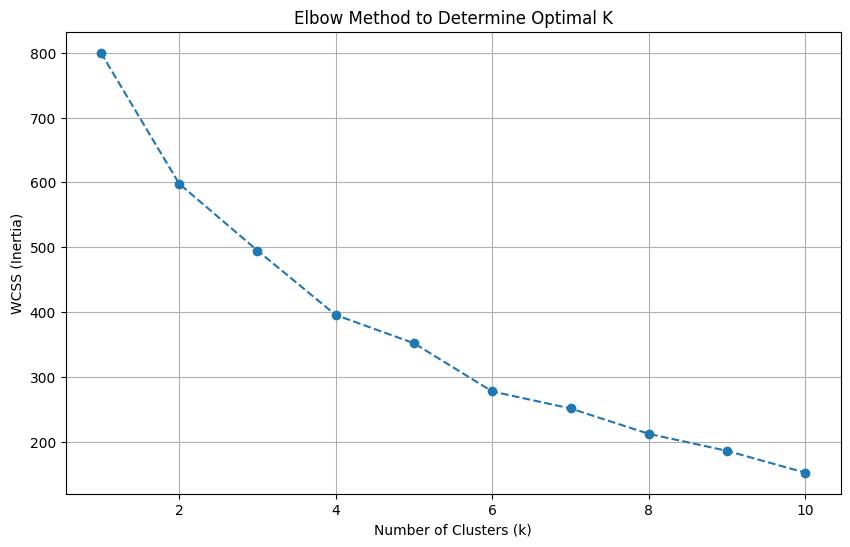

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# A list to store the WCSS for each k
wcss = []

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state = 42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method to Determine Optimal K')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

## Insights from Clustering

In [7]:
from sklearn.cluster import KMeans
import pandas as pd

# Run k-means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)

# Fit K-Means to the scaled data and get cluster labels
clusters = kmeans.fit_predict(X_scaled)

# Add the new cluster labels to the original DataFrame
df_clusters = df.drop(columns=['Cluster'], errors='ignore').copy()
df_clusters['Cluster'] = clusters

# Group by cluster and calculate the mean of relevant features
# Note: 'Gender_Male' needs to be handled from X directly, or be part of df_3_clusters after dummy encoding
# For simplicity, let's use the original unscaled features for interpretation, along with the Gender_Male from X
cluster_summary = df_clusters.groupby('Cluster').agg({
    'Age': 'mean',
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Gender': lambda x: (x == 'Male').sum() / len(x) * 100 # Percentage of Males
}).rename(columns={'Gender': '% Male'}).round(2)

display(cluster_summary)

,Age,Annual Income (k$),Spending Score (1-100),% Male
Cluster,,,,
0,52.17,46.68,39.30,39.44
1,40.23,91.34,20.63,62.86
2,28.28,59.59,69.45,40.43


### Interpretation of 3 Customer Segments:

Based on the summary statistics above, we can interpret the characteristics of each cluster:

*   **Cluster 0:** Older predominantly female, with low annual income, and moderate spending score ('budget-conscious' older female shoppers).
*   **Cluster 1:** Older predominantly male, with very high average income, but very low spending score ('high-income, low-spending' older male customers)
*   **Cluster 2:** Younger customers with moderate annual income but high spending scores ('high-value' young spenders).